In [1]:
import os

# Create the results directory for Part 3
if not os.path.exists('results'):
    os.makedirs('results')
    print("Created 'results' folder.")

Created 'results' folder.


In [3]:
with open('requirements.txt', 'w') as f:
    f.write('pandas\nnumpy\nmatplotlib\nseaborn\nscikit-learn\ntensorflow\nnltk')

Total Records: 1500

--- Sentiment Distribution ---
sentiment_label
neutral     524
negative    497
positive    479
Name: count, dtype: int64

Average Message Length: 12.72 words


/tmp/ipykernel_4247/2346084008.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sentiment_label', data=df, palette='magma')


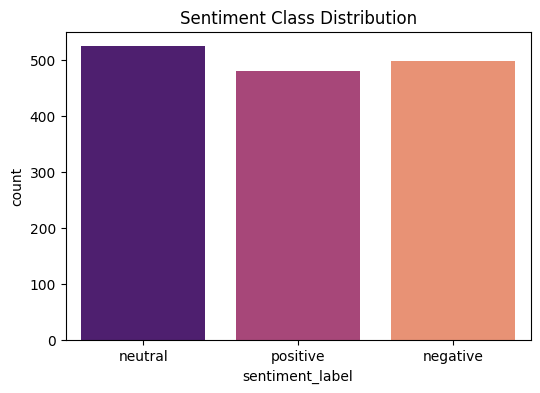


--- Sample Messages ---


,customer_message,sentiment_label
0,I need information about the payment process. ...,neutral
1,I need information about the payment process.,neutral
2,The refund process was fast and convenient. I ...,positive
3,My refund is still pending and this experience...,negative
4,Please tell me how to update my account details.,neutral


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv('customer_support_text_classification.csv')

# 1. Number of records
print(f"Total Records: {len(df)}")

# 2. Target labels and distribution
print("\n--- Sentiment Distribution ---")
print(df['sentiment_label'].value_counts())

# 3. Average text length (based on word count provided or calculated)
df['calculated_len'] = df['customer_message'].apply(lambda x: len(str(x).split()))
print(f"\nAverage Message Length: {df['calculated_len'].mean():.2f} words")

# 4. Visualization
plt.figure(figsize=(6, 4))
sns.countplot(x='sentiment_label', data=df, palette='magma')
plt.title('Sentiment Class Distribution')
plt.savefig('results/sentiment_distribution.png')
plt.show()

# 5. Show sample records
print("\n--- Sample Messages ---")
display(df[['customer_message', 'sentiment_label']].head())

In [5]:
import re
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = str(text).lower() # Lowercasing
    text = re.sub(r'[^a-z\s]', '', text) # Removing special characters/numbers
    tokens = text.split()
    tokens = [word for word in tokens if word not in stop_words] # Removing stopwords
    return " ".join(tokens)

# Apply cleaning
df['clean_message'] = df['customer_message'].apply(clean_text)

# Task 3: Vectorization (TF-IDF)
# We convert text to vectors because models can only perform mathematical operations on numbers.
tfidf = TfidfVectorizer(max_features=1000)
X_tfidf = tfidf.fit_transform(df['clean_message']).toarray()

# Encode labels
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(df['sentiment_label'])

print("Text cleaned and vectorized using TF-IDF.")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Text cleaned and vectorized using TF-IDF.


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

X_train_tf, X_test_tf, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.2, random_state=42)

# Baseline Logistic Regression
baseline_model = LogisticRegression()
baseline_model.fit(X_train_tf, y_train)

# Evaluate
y_pred_base = baseline_model.predict(X_test_tf)
print(f"Baseline Accuracy: {accuracy_score(y_test, y_pred_base):.4f}")

# Save baseline report to results
report = classification_report(y_test, y_pred_base)
with open('results/model_evaluation.csv', 'w') as f:
    f.write(report)

print("\nBaseline Evaluation Complete.")

Baseline Accuracy: 1.0000

Baseline Evaluation Complete.


In [7]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

# 1. Tokenize for Sequences
tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(df['clean_message'])
sequences = tokenizer.texts_to_sequences(df['clean_message'])
X_seq = pad_sequences(sequences, maxlen=50) # Padding to ensure same length

X_train_seq, X_test_seq, y_train_seq, y_test_seq = train_test_split(X_seq, y, test_size=0.2, random_state=42)

# 2. Build LSTM Model
model = Sequential([
    Embedding(input_dim=5000, output_dim=64, input_length=50), # Word Embeddings
    LSTM(64, return_sequences=False),                          # Sequence Layer
    Dropout(0.2),
    Dense(3, activation='softmax')                             # Output for 3 classes
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# 3. Train
print("Starting LSTM Training...")
history = model.fit(X_train_seq, y_train_seq, epochs=5, batch_size=32, validation_split=0.1, verbose=1)

# 4. Save Sample Predictions
test_samples = df['customer_message'].iloc[:5].tolist()
test_seq = pad_sequences(tokenizer.texts_to_sequences(test_samples), maxlen=50)
preds = model.predict(test_seq).argmax(axis=1)
pred_labels = le.inverse_transform(preds)

with open('results/sample_predictions.txt', 'w') as f:
    for msg, lbl in zip(test_samples, pred_labels):
        f.write(f"Message: {msg}\nPredicted Sentiment: {lbl}\n\n")

print("LSTM results and sample predictions saved.")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Starting LSTM Training...
Epoch 1/5
34/34 ━━━━━━━━━━━━━━━━━━━━ 6s 65ms/step - accuracy: 0.5713 - loss: 0.9934 - val_accuracy: 0.7250 - val_loss: 0.7164
Epoch 2/5
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.9250 - loss: 0.3532 - val_accuracy: 1.0000 - val_loss: 0.0597
Epoch 3/5
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 1.0000 - loss: 0.0219 - val_accuracy: 1.0000 - val_loss: 0.0062
Epoch 4/5
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 1.0000 - loss: 0.0045 - val_accuracy: 1.0000 - val_loss: 0.0024
Epoch 5/5
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 1.0000 - loss: 0.0024 - val_accuracy: 1.0000 - val_loss: 0.0014
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step
LSTM results and sample predictions saved.


In [8]:
# TASK 6: FINAL REFLECTION
# 1. Weights and Biases: Weights determine feature importance, while biases shift the activation.
# 2. Activation Functions: These are needed to introduce non-linearity...
# 3. Learning Rate: Too high causes overshooting, too low makes training too slow.